# COSC 424/525 – Project 1: Convolutional Neural Networks – The In's and Out's
**(Due Mar. 19 | 10% Bonus if submitted 24 h before deadline)**

**Objective:** Develop a deep, implementation-level understanding of CNNs and their applications in computer vision:

1. **Task 1 (424/525):** Build and train **VGG16** from scratch on CIFAR-10.
2. **Task 2 (525 only):** Build and train **ResNet-20** from scratch on CIFAR-10.
3. **Task 3 (424/525):** Fine-tune a **pretrained ResNet-50** (ImageNet) for CIFAR-10 classification.
4. **Task 4 (424/525):** **Performance evaluation** – ablation study on batch normalization, batch size, and learning rate.

**Dataset:** CIFAR-10 (10 classes, 60 000 images, 32×32 color).

**Reference notebook:** `LeNet.ipynb` – follow the same conventions:
- Custom `forward()` (not `nn.Sequential` only)
- TensorBoard for training/validation loss and accuracy curves
- Report FLOPs

---

## Instructions
1. Set your class section below.
2. **Do NOT delete empty test cells.**
3. Run every cell top-to-bottom before submitting.
4. Submit **only this notebook**.

---

## Student Information

Set `CLASS_SECTION` to `"COSC424"` or `"COSC525"`.

In [ ]:
# TODO: Set your class section
# Set CLASS_SECTION to "COSC424" or "COSC525"
# YOUR CODE HERE
raise NotImplementedError()

print(f"Class Section: {CLASS_SECTION}")

In [ ]:
assert CLASS_SECTION in ["COSC424", "COSC525"], (
    f"CLASS_SECTION must be 'COSC424' or 'COSC525', got '{CLASS_SECTION}'"
)
print(f"✓ Valid class section: {CLASS_SECTION}")

---

## Setup – Imports & Device

In [ ]:
import os
import shutil
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tv_models
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

In [ ]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# Set random seeds for reproducibility - DON'T MODIFY
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Random seed set to: {RANDOM_SEED}")

---

## Data Loading – CIFAR-10

Load CIFAR-10 with standard preprocessing:
- **Train:** random horizontal flip + random crop (pad=4) + normalize
- **Test:** normalize only
- Normalization: mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)

Create `DataLoader` objects `train_loader` and `test_loader`.
For Task 4 you will need to vary the batch size; define a helper `get_loaders(batch_size)`.

> **Adapt from LeNet:** CIFAR-10 uses **3-channel (RGB)** 32×32 images (LeNet used grayscale 28×28).

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


def get_loaders(batch_size=128, data_root="./data"):
    """Return (train_loader, test_loader) for CIFAR-10."""
    # HINT: Use torchvision.datasets.CIFAR10 and torchvision.transforms
    # You can apply data augmentation (random horizontal flip and random crop)
    # to the training set, but not to the test set.
    # HINT: Use the CIFAR10_MEAN and CIFAR10_STD constants to normalize the data.
    # YOUR CODE HERE
    raise NotImplementedError()
    return train_loader, test_loader


# Default loaders (batch_size=128)
train_loader, test_loader = get_loaders(batch_size=128)

CLASSES = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")
print(f"Classes          : {CLASSES}")

---

## Utility Functions

Implement shared training/evaluation helpers used by all tasks.

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train model for one epoch. Returns (avg_loss, accuracy%)."""
    # HINT: Set model to training mode, iterate through loader batches,
    # compute loss, backpropagate, and update weights. Track loss and accuracy.
    # YOUR CODE HERE
    raise NotImplementedError()
    return running_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a data loader. Returns (avg_loss, accuracy%)."""
    # HINT: Set model to eval mode, disable gradients with torch.no_grad(),
    # iterate through loader, and compute loss and accuracy.
    # YOUR CODE HERE
    raise NotImplementedError()
    return running_loss / len(loader), 100.0 * correct / total


def count_flops(model, input_size=(1, 3, 32, 32)):
    """
    Estimate multiply-accumulate (MAC) operations using forward hooks.
    Returns total FLOPs (2 * MACs).
    """
    # HINT: Register forward hooks on Conv2d and Linear layers to count MACs.
    # For Conv2d: MACs = batch * out_channels * out_h * out_w * in_channels * kH * kW
    # For Linear: MACs = output.numel() * in_features
    # YOUR CODE HERE
    raise NotImplementedError()
    return 2 * total_macs[0]  # 1 MAC = 2 FLOPs


def run_experiment(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs,
    tag,
    device,
    tb_writer=None,
):
    """
    Full training loop with optional TensorBoard logging.
    Returns history dict with keys 'train_loss', 'train_acc', 'val_loss', 'val_acc'.
    """
    # HINT: Loop through epochs, call train_epoch and evaluate, step scheduler,
    # append results to history, and optionally log to TensorBoard.
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    # YOUR CODE HERE
    raise NotImplementedError()
    print(f"  Training time: {elapsed:.1f}s  |  Final Val Acc: {va_acc:.2f}%")
    return history


print("✓ Utility functions defined: train_epoch, evaluate, count_flops, run_experiment")

---

## Task 1: VGG16 from Scratch

### Architecture

Implement **VGG16** adapted for **CIFAR-10 (32×32 RGB → 10 classes)**.

VGG16 configuration (standard, Simonyan & Zisserman 2014):

| Block | Layers | Channels |
|-------|--------|----------|
| 1 | Conv×2 + MaxPool | 64 |
| 2 | Conv×2 + MaxPool | 128 |
| 3 | Conv×3 + MaxPool | 256 |
| 4 | Conv×3 + MaxPool | 512 |
| 5 | Conv×3 + MaxPool | 512 |
| Classifier | FC(512)→FC(512)→FC(10) | – |

**CIFAR-10 adaptation:**  
- All convolutions use **3×3 kernel, padding=1** (same as original).  
- After 5 MaxPool layers on a 32×32 input → 1×1 feature maps.  
  Use `nn.AdaptiveAvgPool2d((1, 1))` before the classifier to handle this.  
- **Batch Normalization** after each Conv (controlled by `batch_norm` flag – needed for Task 4).  
- Classifier: Linear(512, 512) → ReLU → Dropout(0.5) → Linear(512, 512) → ReLU → Dropout(0.5) → Linear(512, 10).  
- Use a **custom `forward()`** method (not a single `nn.Sequential`).

**Training setup:**  
- Optimizer: SGD (lr=0.05, momentum=0.9, weight_decay=5e-4)  
- LR schedule: CosineAnnealingLR (T_max=num_epochs)  
- Loss: CrossEntropyLoss  
- Epochs: 5  
- TensorBoard: log loss and accuracy curves

In [ ]:
class VGG16(nn.Module):
    """
    VGG-16 adapted for CIFAR-10 (32×32 RGB, 10 classes).

    Reference: Simonyan & Zisserman, "Very Deep Convolutional Networks for
    Large-Scale Image Recognition", ICLR 2015.

    Adaptation:  AdaptiveAvgPool2d replaces the original fixed 7×7 avg pool so
    the same architecture works for the 32×32 CIFAR-10 input.
    """

    # fmt: off
    CFG = [64, 64, 'M',
           128, 128, 'M',
           256, 256, 256, 'M',
           512, 512, 512, 'M',
           512, 512, 512, 'M']
    # fmt: on

    def __init__(self, num_classes: int = 10, batch_norm: bool = True):
        super().__init__()
        # HINT: Iterate through CFG, building Conv2d layers with optional BatchNorm2d.
        # 'M' means MaxPool2d. Then add AdaptiveAvgPool2d and classifier.
        # YOUR CODE HERE
        raise NotImplementedError()
        self._initialize_weights()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # HINT: Pass input through features, avgpool, flatten, then classifier.
        # YOUR CODE HERE
        raise NotImplementedError()
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)


print("VGG16 class defined.")

### VGG16 FLOPs and Parameters

Calculate the computational complexity and model size.

In [ ]:
# ── FLOPs ─────────────────────────────────────────────────────────────────────
# TODO: Calculate FLOPs and parameters for VGG16
# YOUR CODE HERE
raise NotImplementedError()
print(f"VGG16 – FLOPs        : {vgg16_flops / 1e9:.3f} GFLOPs")
print(f"VGG16 – Parameters   : {total_params / 1e6:.2f} M")

### Training VGG16

Train VGG16 for 7 epochs using SGD with cosine annealing learning rate schedule.

In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────
NUM_EPOCHS_VGG = 5  # DON'T MODIFY

# HINT:
# - Create VGG16, criterion ...
# - Use run_experiment()

# Clean up previous runs
if os.path.exists("runs/vgg16"):
    shutil.rmtree("runs/vgg16")
writer_vgg = SummaryWriter("runs/vgg16")
# YOUR CODE HERE
raise NotImplementedError()

writer_vgg.close()
vgg16_final_acc = history_vgg["val_acc"][-1]
print(f"\nVGG16 Final Validation Accuracy: {vgg16_final_acc:.2f}%")

### Training Curves

Visualize training and validation loss/accuracy over epochs.

#### Expected Output:
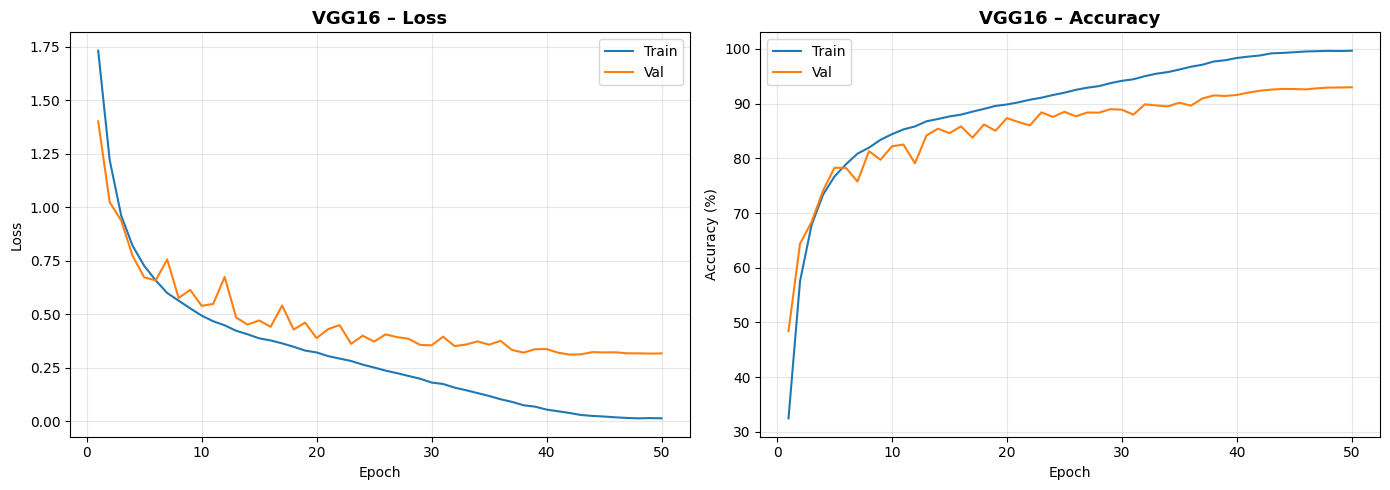

In [ ]:
# TODO: Plot training and validation loss/accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS_VGG + 1)

# YOUR CODE HERE
raise NotImplementedError()

plt.tight_layout()
plt.savefig("vgg16_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curves saved to vgg16_curves.png")

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs/vgg16

---

## Task 2: ResNet-20 from Scratch *(COSC525 only)*

### Architecture

Implement **ResNet-20** as described in He et al. (2016) for CIFAR-10.

**Specification:**

- **Initial layer:** Conv(3→16, 3×3, stride=1, padding=1) + BN + ReLU *(no pooling)*
- **Stage 1:** 3 × `BasicBlock(16, 16, stride=1)` → feature map 32×32
- **Stage 2:** 3 × `BasicBlock(16→32, stride=2) + 2×BasicBlock(32,32,stride=1)` → 16×16
- **Stage 3:** 3 × `BasicBlock(32→64, stride=2) + 2×BasicBlock(64,64,stride=1)` → 8×8
- **Head:** `AdaptiveAvgPool2d(1)` → `Flatten` → `Linear(64, 10)`
- **Total conv layers:** 20  (6n+2, n=3)

**BasicBlock:**

$$\text{BasicBlock}(x) = \text{ReLU}\bigl(F(x) + \text{shortcut}(x)\bigr)$$

where $F(x) = \text{BN}(\text{Conv}(\text{ReLU}(\text{BN}(\text{Conv}(x)))))$.  
The shortcut is identity when dimensions match, otherwise a 1×1 conv + BN.

**Training setup:**  
- SGD (lr=0.1, momentum=0.9, weight_decay=1e-4)  
- MultiStepLR: γ=0.1 at epochs 5, 8  
- Epochs: 5  
- TensorBoard: loss and accuracy curves

In [ ]:
if CLASS_SECTION == "COSC424":
    pass
else:

    class BasicBlock(nn.Module):
        """
        Residual building block for ResNet-20 (CIFAR-10 variant).

        F(x) = BN → ReLU → Conv3×3 → BN → Conv3×3 → BN
        out  = ReLU( F(x) + shortcut(x) )
        """

        expansion = 1

        def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
            super().__init__()
            # HINT: Create two Conv2d layers with BatchNorm2d. Add a shortcut that
            # uses 1x1 conv + BN if dimensions change, otherwise identity.
            # YOUR CODE HERE
            raise NotImplementedError()

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            # HINT: Apply conv1->bn1->relu, then conv2->bn2, add shortcut(x), then relu.
            # YOUR CODE HERE
            raise NotImplementedError()
            return out

    class ResNet20(nn.Module):
        """
        ResNet-20 for CIFAR-10 (He et al., 2016).
        Architecture: 6n+2 = 20 layers with n=3 blocks per stage.
        """

        def __init__(self, num_classes: int = 10):
            super().__init__()
            # HINT: Start with conv1 (3->16), then create 3 stages with _make_stage,
            # add avgpool and fc layer. Call _initialize_weights at the end.
            # YOUR CODE HERE
            raise NotImplementedError()
            self._initialize_weights()

        def _make_stage(
            self, out_channels: int, n_blocks: int, stride: int
        ) -> nn.Sequential:
            # HINT: Create n_blocks BasicBlocks. First block uses the given stride,
            # remaining blocks use stride=1. Update self.in_channels after each block.
            strides = [stride] + [1] * (n_blocks - 1)
            layers = []
            # YOUR CODE HERE
            raise NotImplementedError()
            return nn.Sequential(*layers)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            # HINT: Pass through conv1->bn1->relu, then stage1, stage2, stage3,
            # avgpool, flatten, and fc.
            # YOUR CODE HERE
            raise NotImplementedError()
            return x

        def _initialize_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(
                        m.weight, mode="fan_out", nonlinearity="relu"
                    )
                elif isinstance(m, nn.BatchNorm2d):
                    nn.init.ones_(m.weight)
                    nn.init.zeros_(m.bias)
                elif isinstance(m, nn.Linear):
                    nn.init.normal_(m.weight, 0, 0.01)
                    nn.init.zeros_(m.bias)

    print("BasicBlock and ResNet20 classes defined.")

### ResNet-20 FLOPs and Parameters

Calculate the computational complexity and model size.

In [ ]:
# TODO: Calculate FLOPs and parameters for ResNet-20
# YOUR CODE HERE
raise NotImplementedError()
print(f"ResNet-20 – FLOPs      : {resnet20_flops / 1e6:.1f} MFLOPs")
print(f"ResNet-20 – Parameters : {resnet20_params / 1e3:.1f} K")

### Training ResNet-20

Train ResNet-20 for 5 epochs with MultiStepLR schedule (COSC525 only).

In [ ]:
# Skip Task 2 training if class section is COSC424
if CLASS_SECTION == "COSC525":
    NUM_EPOCHS_RN20 = 5  # DO NOT CHANGE – 5 epochs is should be enough to see >70% accuracy if implemented correctly

    if os.path.exists("runs/resnet20"):
        shutil.rmtree("runs/resnet20")
    writer_rn20 = SummaryWriter("runs/resnet20")
    # YOUR CODE HERE
    raise NotImplementedError()
    writer_rn20.close()
    rn20_final_acc = history_rn20["val_acc"][-1]
    print(f"\nResNet-20 Final Validation Accuracy: {rn20_final_acc:.2f}%")
else:
    print("Task 2 is for COSC525 students only. Skipping.")
    history_rn20 = None
    rn20_final_acc = None

### Training Curves

Visualize ResNet-20 training and validation loss/accuracy over epochs.

#### Expected Plot:
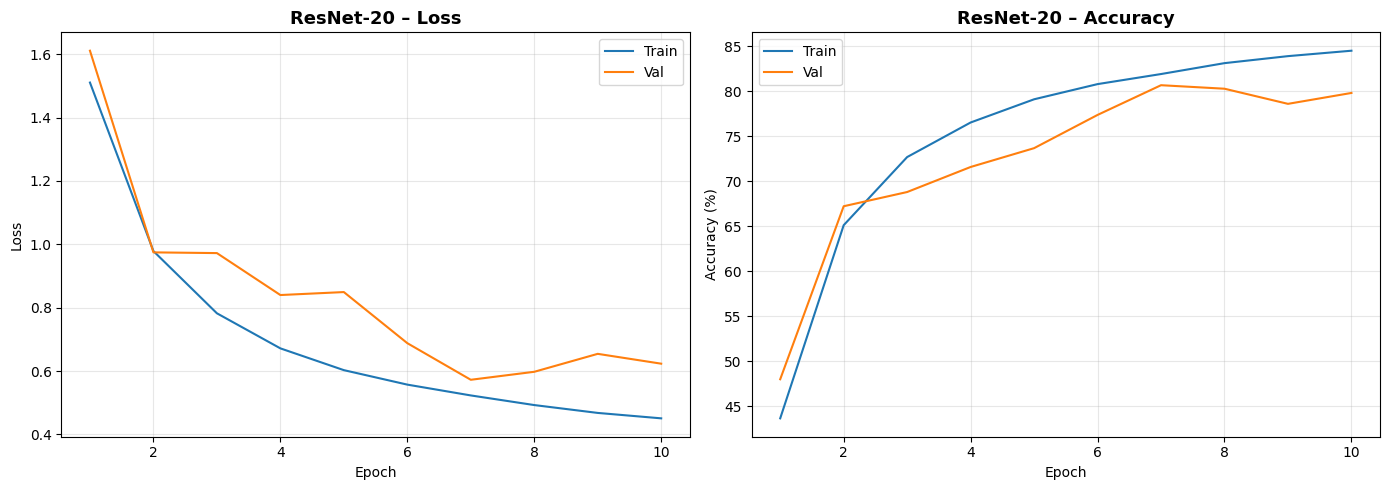

In [ ]:
if CLASS_SECTION == "COSC525" and history_rn20 is not None:
    # TODO: Plot training and validation curves for ResNet-20
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, NUM_EPOCHS_RN20 + 1)
    # YOUR CODE HERE
    raise NotImplementedError()
    plt.tight_layout()
    plt.savefig("resnet20_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

---

## Task 3: Fine-tune Pretrained ResNet-50

### Instructions

Download a **ResNet-50 pretrained on ImageNet** from `torchvision.models` and adapt it for CIFAR-10.

**Required modifications:**
1. **Stem:** Replace `conv1` (7×7, stride=2) with a 3×3, stride=1, padding=1 conv so 32×32 inputs are not downsampled too aggressively.
2. **Remove** the first `MaxPool2d` layer (replace with `nn.Identity()`).
3. **Classifier:** Replace `model.fc` with `nn.Linear(2048, 10)`.

### Progressive unfreezing approach: Fine-tuning strategy to implement
- **Head-only fine-tuning:** freeze all layers except the final FC layer for the first `HEAD_EPOCHS` epochs, then unfreeze and continue.
> The pretrained ImageNet features are valuable; training the head first with frozen backbone prevents destroying these features with random gradients from an untrained classifier. Allows the new classification head to adapt to the target distribution before fine-tuning deeper layers

**Training setup:**  
- Optimizer: Adam (lr=1e-3, weight_decay=1e-4)  
- LR schedule: StepLR (step_size=5, gamma=0.5)  
- Epochs: 5 (head-only: first 2 epochs frozen, then 3 full fine-tune)  
- TensorBoard: loss and accuracy

In [ ]:
def build_resnet50_cifar10(
    pretrained: bool = True, freeze_backbone: bool = False
) -> nn.Module:
    """
    Build ResNet-50 adapted for CIFAR-10.

    Args:
        pretrained:       Load ImageNet pretrained weights.
        freeze_backbone:  If True, freeze all layers except the final FC.

    Returns:
        Modified ResNet-50 nn.Module.
    """
    # HINT: Load ResNet-50 from torchvision.models, replace conv1 with 3x3 stride=1,
    # replace maxpool with nn.Identity(), replace fc with Linear(in_features, 10).
    # If freeze_backbone, set requires_grad=False for all params except fc.
    # Note: You can use tv_models.ResNet50_Weights.IMAGENET1K_V1 for pretrained weights.
    # YOUR CODE HERE
    raise NotImplementedError()
    return model


# Verify
# Output shape should be (2, 10)
_rn50 = build_resnet50_cifar10(pretrained=False).to(device)
with torch.no_grad():
    _out50 = _rn50(torch.randn(2, 3, 32, 32).to(device))
print(f"ResNet-50 (CIFAR-10 adapted) output shape: {tuple(_out50.shape)}")

### Fine-tuning ResNet-50

Fine-tune pretrained ResNet-50 with progressive unfreezing strategy.

In [ ]:
NUM_EPOCHS_RN50 = 5  # DON'T MODIFY
HEAD_EPOCHS = 2  # epochs with frozen backbone

# ── Head-only fine-tuning ─────────────────────────────────────────────────────
if os.path.exists("runs/resnet50"):
    shutil.rmtree("runs/resnet50")
writer_rn50 = SummaryWriter("runs/resnet50")

# YOUR CODE HERE
raise NotImplementedError()

writer_rn50.close()
rn50_final_acc = history_rn50["val_acc"][-1]
print(f"\nResNet-50 Final Validation Accuracy: {rn50_final_acc:.2f}%")

### Training Curves

Visualize ResNet-50 fine-tuning progress with backbone unfreezing marker.

#### Sample Output:
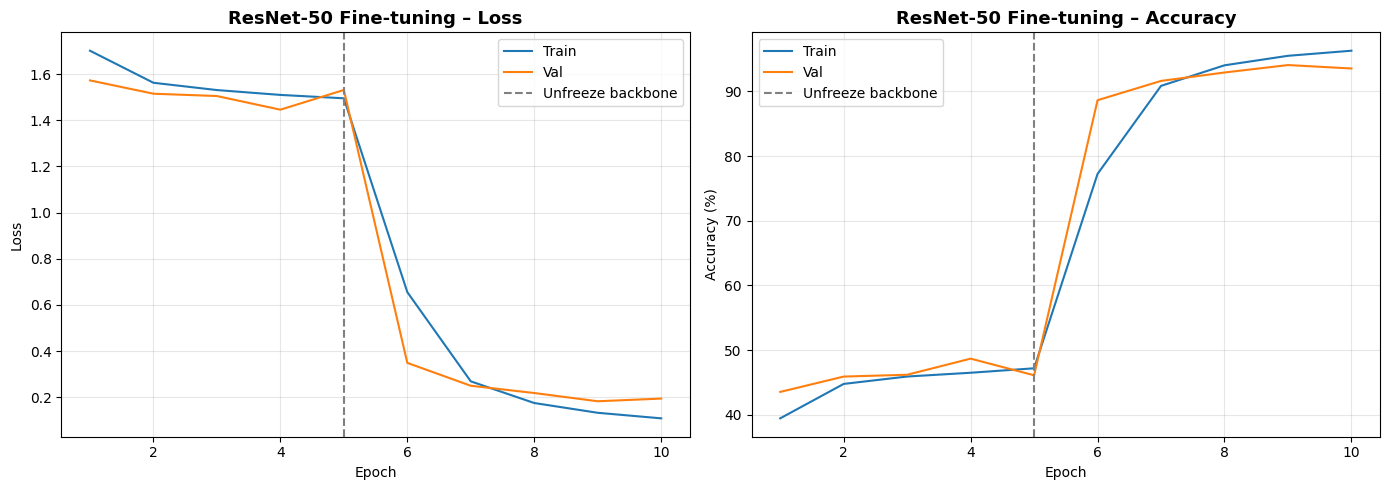

In [ ]:
# TODO: Plot training curves for ResNet-50 fine-tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
erange = range(1, NUM_EPOCHS_RN50 + 1)
# HINT: Plot train/val loss and accuracy. Add vertical line at HEAD_EPOCHS to show when backbone was unfrozen.
# YOUR CODE HERE
raise NotImplementedError()
plt.tight_layout()
plt.savefig("resnet50_finetune.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Task 4: Performance Evaluation – Ablation Study

Systematically study the effect of three factors using **VGG16 on CIFAR-10**.  
For each experiment, train for **`ABLATION_EPOCHS` epochs** (default = 10) and record final validation accuracy.

### 4a) Effect of Batch Normalization

Train VGG16 **with** and **without** Batch Normalization using the same hyperparameters.

### 4b) Effect of Batch Size

Train VGG16 with batch sizes: **32, 64, 128, 256**.

### 4c) Effect of Learning Rate

Train VGG16 with SGD learning rates: **0.1, 0.01, 0.001**.

Store all results in a dictionary `ablation_results` with structure:
```python
ablation_results = {
    'bn':         {'with_bn': <acc>, 'without_bn': <acc>},
    'batch_size': {32: <acc>, 64: <acc>, 128: <acc>, 256: <acc>},
    'lr':         {0.1: <acc>, 0.01: <acc>, 0.001: <acc>},
}
```

### Ablation Training Function

Define a helper function to train VGG16 with varying hyperparameters.

In [ ]:
ABLATION_EPOCHS = 5  # DON'T MODIFY


def ablation_train(
    batch_norm=True, batch_size=128, lr=0.05, num_epochs=ABLATION_EPOCHS
):
    """
    Train VGG16 with given hyperparameters for ablation study.
    Returns final validation accuracy (%).
    """
    # HINT: Create data loaders, instantiate VGG16 with specified batch_norm,
    # create optimizer and scheduler, train for num_epochs, and return final val accuracy.
    # YOUR CODE HERE
    raise NotImplementedError()
    return val_acc

### Running Ablation Experiments

Execute ablation studies on batch normalization, batch size, and learning rate.

In [ ]:
# TODO: Run ablation study experiments
ablation_results = {
    "bn": {},
    "batch_size": {},
    "lr": {},
}

# HINT: For each experiment, call ablation_train with the appropriate hyperparameters, store results in ablation_results dict, and print results in a clear format.
# For example, for batch normalization:
# for use_bn in [True, False]:
#     acc = ablatio..
#
# Initially, you can use the same batch_size=128 and lr=0.05, update each parameter once you complete their ablation.
# Use the best hyperparameters in preceding ablation when testing the next ones (You would need run this cell multiple times to get and fix the best preceding hyperparameters).

# ── 4a) Batch Normalization ───────────────────────────────────────────────────
print("=" * 65)
print("Task 4a: Effect of Batch Normalization")
print("=" * 65)
# YOUR CODE HERE
raise NotImplementedError()

# ── 4b) Batch Size ────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("Task 4b: Effect of Batch Size")
print("=" * 65)
# YOUR CODE HERE
raise NotImplementedError()

# ── 4c) Learning Rate ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("Task 4c: Effect of Learning Rate")
print("=" * 65)
# YOUR CODE HERE
raise NotImplementedError()

print("\n✓ Ablation study complete")
print(ablation_results)

### Ablation Study Visualization

Create comparative plots showing the effect of each hyperparameter.

#### Sample Output:
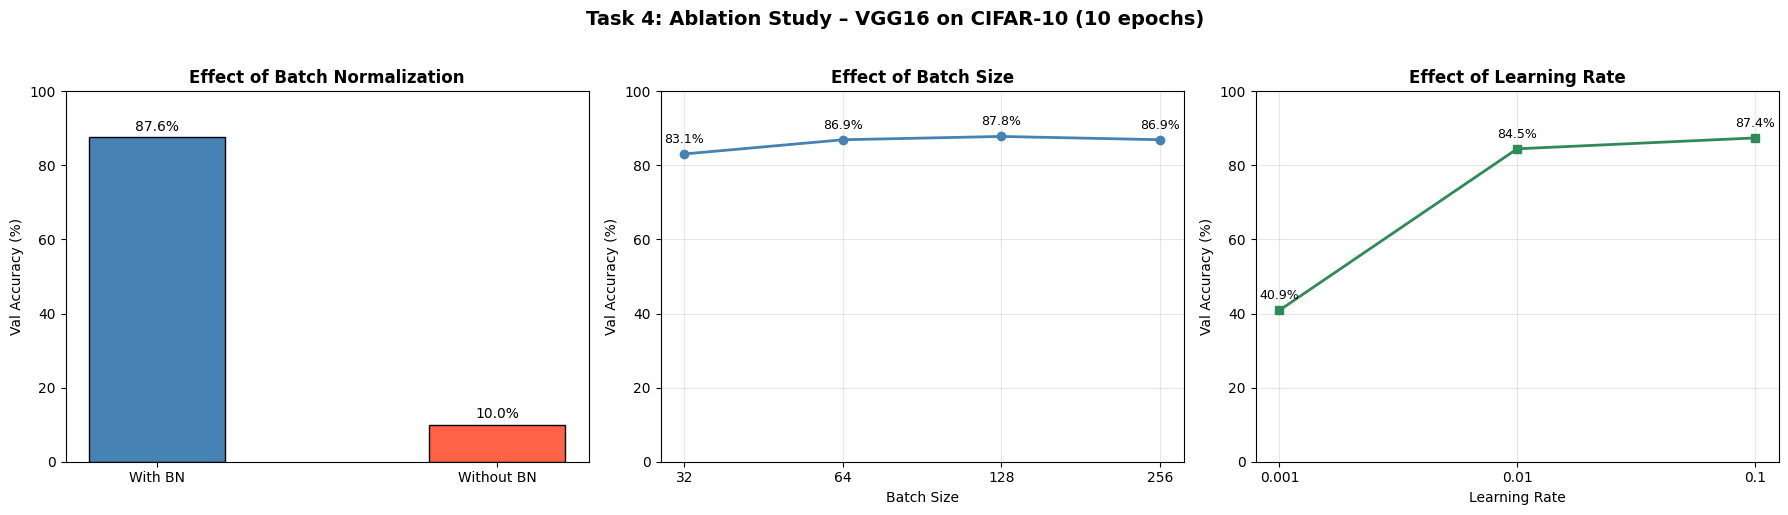

In [ ]:
# TODO: Visualize ablation study results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# YOUR CODE HERE
raise NotImplementedError()
plt.tight_layout()
plt.savefig("task4_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ablation study plots saved to task4_ablation.png")

---

## Summary: Print Final Results (DON'T MODIFY)

In [ ]:
print("=" * 65)
print("FINAL SUMMARY")
print("=" * 65)
print(f"  VGG16 val accuracy          : {vgg16_final_acc:.2f}%")
if CLASS_SECTION == "COSC525" and rn20_final_acc is not None:
    print(f"  ResNet-20 val accuracy       : {rn20_final_acc:.2f}%")
print(f"  ResNet-50 val accuracy       : {rn50_final_acc:.2f}%")
print()
print("  Ablation study results:")
print(f"    BN:         {ablation_results['bn']}")
print(f"    Batch size: {ablation_results['batch_size']}")
print(f"    LR:         {ablation_results['lr']}")
print("=" * 65)